# **필요한 라이브러리 불러오기**

In [ ]:
import numpy as np
import torch
import torch.nn as nn
import torchvision
from torchvision import transforms
import matplotlib.pyplot as plt
from torchvision.transforms.functional import to_pil_image
import torch.nn.functional as F

# **MNIST 데이터셋 불러오기**
- 60,000개의 train data, 10,000개의 test data

In [ ]:
# GPU로 연산.
device = 'cuda' if torch.cuda.is_available() else 'cpu'

# 랜덤 시드 고정.
# 실험 조건을 동일하게 설정하여,
# 같은 input을 넣으면 같은 결과가 나올 수 있도록 함.
torch.manual_seed(777)
if device == 'cuda':
    torch.cuda.manual_seed_all(777)

In [ ]:
# MNIST dataset
# 60,000개의 train data, 10,000개의 test data
mnist_train = torchvision.datasets.MNIST(root='MNIST_data/', # 다운로드 경로 지정
                          train=True, # True를 지정하면 훈련 데이터로 다운로드
                          transform=transforms.ToTensor(), # 텐서로 변환
                          download=True)

mnist_test = torchvision.datasets.MNIST(root='MNIST_data/', # 다운로드 경로 지정
                         train=False, # False를 지정하면 테스트 데이터로 다운로드
                         transform=transforms.ToTensor(), # 텐서로 변환
                         download=True)

100%|██████████| 9.91M/9.91M [00:00<00:00, 18.6MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 490kB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 4.68MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 13.6MB/s]


In [ ]:
# dataset 크기 출력
print(len(mnist_train))
print(len(mnist_test))

60000
10000


# **Data Augmentation 적용**

아래 셀을 순서대로 실행하고, TODO를 작성하여 MNIST 학습 데이터에 Augmentation을 적용하세요.

- 원본 이미지와 증강된 이미지를 비교하여 변환 결과를 확인하세요.
- 증강 데이터를 원본 학습 데이터와 결합하세요.
- 이후 DataLoader 생성, 모델 설계, 학습 및 평가 순서로 진행하세요.

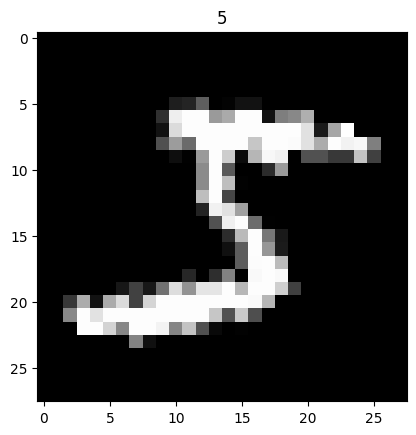

In [ ]:
# RandomAffine 적용 후 데이터 시각화
plt.imshow(torchvision.transforms.RandomAffine((10,30))(to_pil_image(mnist_train.data[0])), cmap='gray')
plt.title('%s' % mnist_train[0][1])
plt.show()

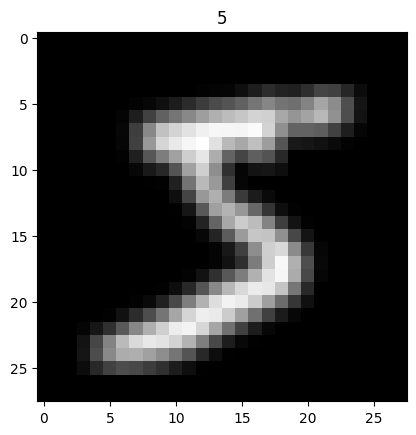

In [ ]:
# GaussianBlur 적용 후 데이터 시각화
plt.imshow(transforms.GaussianBlur(kernel_size=3)(to_pil_image(mnist_train.data[0])), cmap='gray')
plt.title('%s' % mnist_train[0][1])
plt.show()

## ✏️ TODO: Data Augmentation 적용하기

아래 코드의 빈칸을 채워 MNIST 학습 데이터에 **두 가지 Data Augmentation**을 적용해 보세요.

- 각 매개변수와 일치하는 augmentation 이름을 작성하세요.
- `degrees`에 최소 회전 각도와 최대 회전 각도를 작성하세요.
- 빈칸을 모두 채운 후 셀을 실행하여 데이터셋을 생성하세요.

In [ ]:
# RandomAffine, GaussianBlur를 적용한 학습 데이터 변환 구성

#  GaussianBlur : 이미지에 가우시안 블러를 적용합니다.
#  RandomAffine : 이미지를 회전, 이동, 확대·축소하거나 기울입니다.

# 기존 매개변수를 확인하고 적용할 augmentation 이름 2가지를 작성하세요.
# degrees=(최소 회전 각도, 최대 회전 각도)

train_transforms = transforms.Compose(
        [

         transforms.ToTensor()
        ])

augmented_data = torchvision.datasets.MNIST(root='MNIST_data/',
                                        train=True,
                                        transform=train_transforms,
                                        download=True)

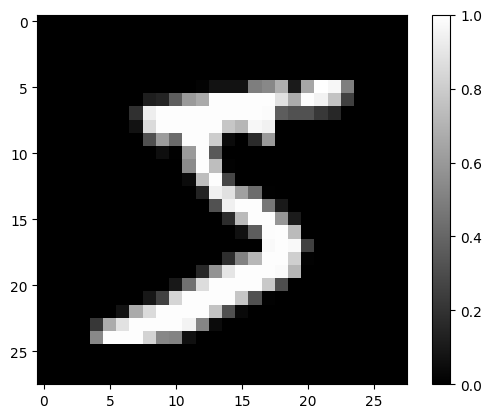

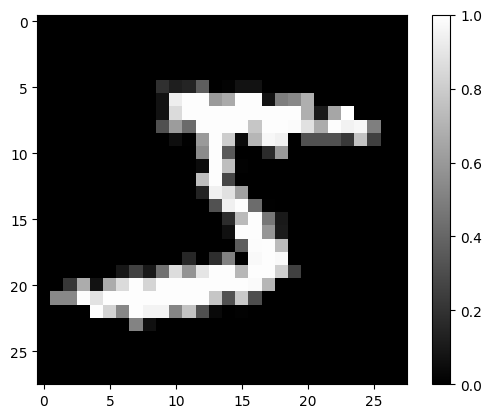

In [ ]:
# 원본 이미지와 증강 이미지 비교

im = mnist_train[0][0][0]
aug_im = augmented_data[0][0][0]

# Normal image
plt.imshow(im, cmap="gray")
plt.colorbar()
plt.show()

# Augmented image
plt.imshow(aug_im, cmap="gray")
plt.colorbar()
plt.show()

In [ ]:
# 증강 데이터 중 20,000개 사용
idx = range(0, 20000)
train_subset = torch.utils.data.Subset(augmented_data, idx)

# 원본 데이터와 증강 데이터를 결합하여 학습 데이터 구성
train_dataset = torch.utils.data.ConcatDataset([mnist_train, train_subset])

# 합쳐진 dataset 크기 출력
print(len(train_dataset))

실험: With Augmentation
학습 데이터 수: 80000


In [ ]:
# 비교 실험에 사용할 batch size를 작성하세요.
batch_size = 128

# Data loader를 사용하여 배치 크기 지정
train_loader=torch.utils.data.DataLoader(train_dataset,
                                        batch_size=batch_size,
                                        shuffle=True)
test_loader = torch.utils.data.DataLoader(mnist_test,
                                          batch_size=batch_size,
                                          shuffle=False)

# **모델 설계**
- MLP

In [ ]:
class Net(nn.Module):
    def __init__(self):
        super(Net,self).__init__()
        # input_layer = 28*28, hidden_layer1 = 512
        self.fc1 = nn.Linear(28*28, 512)
        # hidden_layer1 = 512, hidden_layer2 = 512
        self.fc2 = nn.Linear(512,512)
        # hidden_layer2 = 512, output_layer = 10
        self.fc3 = nn.Linear(512,10)

    def forward(self,x):
        x = x.view(-1,28*28)  # flatten
        x = F.relu(self.fc1(x))
        x = F.relu(self.fc2(x))
        x = self.fc3(x)

        return x

model = Net().to(device) # GPU에서 연산 수행하기 위해 device로 보냄

# **Train: 모델 학습**

In [ ]:
epochs = 15                 # 학습 횟수
learning_rate = 0.01          # 학습률

In [ ]:
# cost function과 optimizer 정의
criterion = nn.CrossEntropyLoss().to(device)
optimizer = torch.optim.SGD(model.parameters(),lr=learning_rate)

In [ ]:
# 모델 학습
model.train()
loss_list = []

for epoch in range(epochs):
  avg_loss = 0.0
  total_loss = 0.0
  for iter, data in enumerate(train_loader):

    # gradient 초기화
    optimizer.zero_grad()

    images, labels = data
    images = images.to(device)
    labels = labels.to(device)

    # 모델에 이미지 입력
    output = model(images)
    loss = criterion(output,labels)

    # 파라미터 업데이트
    loss.backward()
    optimizer.step()

    # 손실값 기록
    avg_loss += loss.item()
    total_loss += loss.item()

    if (iter+1) % 100==0: #100으로 나누어지는 순번일 경우
      print('Train Epoch: {} [{}/{}]\tLoss: {:.5f}'.format(
      epoch, iter+1, len(train_loader), avg_loss/100.)) # 케이스 100개 마다 평균 loss 출력
      avg_loss = 0.0 # 누적 loss 값 초기화
  loss_list.append(total_loss/(iter+1))  # epoch마다 평균 loss를 loss_list에 추가
print('\nLearning finished!')

Train Epoch: 0 [100/625]	Loss: 2.28601
Train Epoch: 0 [200/625]	Loss: 2.24480
Train Epoch: 0 [300/625]	Loss: 2.18448
Train Epoch: 0 [400/625]	Loss: 2.09496
Train Epoch: 0 [500/625]	Loss: 1.93887
Train Epoch: 0 [600/625]	Loss: 1.72011
Train Epoch: 1 [100/625]	Loss: 1.41656
Train Epoch: 1 [200/625]	Loss: 1.20631
Train Epoch: 1 [300/625]	Loss: 1.08328
Train Epoch: 1 [400/625]	Loss: 0.98410
Train Epoch: 1 [500/625]	Loss: 0.88611
Train Epoch: 1 [600/625]	Loss: 0.84913
Train Epoch: 2 [100/625]	Loss: 0.78929
Train Epoch: 2 [200/625]	Loss: 0.74265
Train Epoch: 2 [300/625]	Loss: 0.70827
Train Epoch: 2 [400/625]	Loss: 0.67962
Train Epoch: 2 [500/625]	Loss: 0.67509
Train Epoch: 2 [600/625]	Loss: 0.66331
Train Epoch: 3 [100/625]	Loss: 0.62158
Train Epoch: 3 [200/625]	Loss: 0.61649
Train Epoch: 3 [300/625]	Loss: 0.60988
Train Epoch: 3 [400/625]	Loss: 0.58208
Train Epoch: 3 [500/625]	Loss: 0.58708
Train Epoch: 3 [600/625]	Loss: 0.56019
Train Epoch: 4 [100/625]	Loss: 0.55400
Train Epoch: 4 [200/625]	

# **Test: 모델 성능 확인 및 결과 저장**

사전 학습된 가중치를 불러오지 않고, 현재 실험에서 직접 학습한 모델을 평가합니다.

In [ ]:
# 모델 성능 확인
with torch.no_grad(): # torch.no_grad(): gradient 계산을 수행하지 않음
  model.eval()
  accuracy = 0.0

  for iter, data in enumerate(test_loader):
    images, labels = data
    images = images.to(device)
    labels = labels.to(device)
    output = model(images)
    pred = torch.argmax(output,1) == labels
    accuracy += pred.float().sum()

  accuracy_value = (100 * accuracy / len(mnist_test)).item()

# 마지막 학습 loss와 테스트 Accuracy 출력
print('Loss: {:.4f}'.format(loss_list[-1]))
print('Accuracy: {:.2f}%'.format(accuracy_value))

실험: With Augmentation
Accuracy: 94.02%


## ✏️ 추가 실습: 학습 파라미터와 Augmentation 방법 변경하기

Learning rate, Epoch, Augmentation 방법과 설정값을 변경하면서 학습 결과를 비교해 보세요.

- `learning_rate`: 가중치를 조정하는 정도
- `epochs`: 전체 학습 데이터를 반복하는 횟수
- `RandomAffine`: `degrees`를 변경하여 회전 각도 범위 조절
- `GaussianBlur`: `kernel_size`를 변경하여 블러 효과 비교
- 두 Augmentation을 각각 단독으로 적용하거나 함께 적용하여 결과 비교
- ppt의 여러 augmentation 방법 적용

한 번에 하나의 조건만 변경하고, 나머지 조건은 동일하게 유지하세요.

- `GaussianBlur`의 `kernel_size`는 `3`, `5`, `7` 등 양의 홀수로 설정하세요.
- Augmentation 설정을 변경하면 증강 데이터셋과 DataLoader를 다시 생성하세요.
- 매 실험마다 모델과 옵티마이저를 새로 생성하여 처음부터 학습하세요.
- 각 실험의 설정값, Loss와 Accuracy를 기록하여 비교하세요.
- Augmentation을 적용하지 않은 경우와 비교하여 성능 차이를 확인하세요.